In [ ]:
!pip install datasets transformers scikit-learn

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DefaultDataCollator
import torch
import numpy as np
from sklearn.metrics import f1_score

In [ ]:
dataset = load_dataset("go_emotions")

num_labels = 28

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128,
    )

dataset = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

In [ ]:
def to_multi_hot(example):
    multi_hot = np.zeros(num_labels, dtype=np.float32)
    multi_hot[example["labels"]] = 1.0
    example["labels"] = multi_hot
    return example

dataset = dataset.map(to_multi_hot)

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

In [ ]:
dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [ ]:
train_dataset = dataset["train"].select(range(2000))
val_dataset = dataset["validation"].select(range(500))

print(len(train_dataset), len(val_dataset))

2000 500


In [ ]:
print(dataset["train"][0]["labels"])
print(type(dataset["train"][0]["labels"]))

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1])
<class 'torch.Tensor'>


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
label_names = dataset["train"].features["labels"].feature.names

for i, name in enumerate(label_names):
    print(i, name)

0 admiration
1 amusement
2 anger
3 annoyance
4 approval
5 caring
6 confusion
7 curiosity
8 desire
9 disappointment
10 disapproval
11 disgust
12 embarrassment
13 excitement
14 fear
15 gratitude
16 grief
17 joy
18 love
19 nervousness
20 optimism
21 pride
22 realization
23 relief
24 remorse
25 sadness
26 surprise
27 neutral


In [ ]:
tail_labels = [16, 21, 23, 19, 12, 24, 14, 8]

In [ ]:
def tail_recall(labels, preds):
    recalls = []
    for i in tail_labels:
        true = labels[:, i]
        pred = preds[:, i]

        tp = ((true == 1) & (pred == 1)).sum()
        fn = ((true == 1) & (pred == 0)).sum()

        if tp + fn > 0:
            recalls.append(tp / (tp + fn))

    return np.mean(recalls) if recalls else 0


def compute_metrics(eval_pred):
    logits, labels = eval_pred

    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    preds = (probs > 0.5).astype(int)

    micro_f1 = f1_score(labels, preds, average="micro", zero_division=0)
    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    tail = tail_recall(labels, preds)

    return {
        "micro_f1": micro_f1,
        "macro_f1": macro_f1,
        "tail_recall": tail,
    }

In [ ]:
data_collator = DefaultDataCollator(return_tensors="pt")

class MultiLabelCollator:
    def __call__(self, features):
        batch = data_collator(features)
        batch["labels"] = batch["labels"].float()
        return batch

collator = MultiLabelCollator()

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=50,
    report_to="none",
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collator,
)

In [ ]:
trainer.train()

Step,Training Loss
50,0.371006
100,0.169544
150,0.152735
200,0.148501
250,0.154026
300,0.149688
350,0.144952


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=375, training_loss=0.1822051258087158, metrics={'train_runtime': 76.7676, 'train_samples_per_second': 78.158, 'train_steps_per_second': 4.885, 'total_flos': 198793230336000.0, 'train_loss': 0.1822051258087158, 'epoch': 3.0})

In [ ]:
trainer.evaluate()

{'eval_loss': 0.15197288990020752,
 'eval_micro_f1': 0.0,
 'eval_macro_f1': 0.0,
 'eval_tail_recall': 0.0,
 'eval_runtime': 2.0455,
 'eval_samples_per_second': 244.444,
 'eval_steps_per_second': 15.644,
 'epoch': 3.0}

In [ ]:
pred_output = trainer.predict(val_dataset)

logits = pred_output.predictions
labels = pred_output.label_ids

probs = 1 / (1 + np.exp(-logits))

print(probs[:5])
print("max prob:", probs.max())
print("mean prob:", probs.mean())

[[0.09315    0.05374518 0.03714356 0.05555595 0.08196656 0.0227228
  0.03061561 0.05160494 0.01568858 0.03753496 0.05194178 0.01564823
  0.00927173 0.01847998 0.01230361 0.05924097 0.01029231 0.03615625
  0.05724966 0.00685547 0.03673472 0.00761365 0.01986815 0.00846581
  0.01367086 0.02959294 0.03158618 0.2898562 ]
 [0.09257902 0.0505232  0.03771034 0.05457038 0.07517699 0.02344013
  0.02759644 0.04376639 0.01448344 0.03550874 0.05037282 0.01515777
  0.00915195 0.01639869 0.01136703 0.05578192 0.00986291 0.03375331
  0.04885986 0.0063688  0.03671534 0.00699984 0.01916052 0.00795103
  0.01275542 0.0288596  0.03036043 0.31812683]
 [0.09100565 0.05019072 0.03733028 0.05261567 0.07374188 0.0212977
  0.02797756 0.04508682 0.01441276 0.0354287  0.04986694 0.01477685
  0.00886635 0.01679418 0.01115721 0.05401581 0.00966375 0.0354604
  0.05427362 0.00630464 0.03541281 0.00703524 0.01855469 0.00749725
  0.01233578 0.02906566 0.02897698 0.29637697]
 [0.08286314 0.04703141 0.0370177  0.05472358 

In [ ]:
from sklearn.metrics import f1_score

thresholds = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

for t in thresholds:
    preds = (probs > t).astype(int)

    micro = f1_score(labels, preds, average="micro", zero_division=0)
    macro = f1_score(labels, preds, average="macro", zero_division=0)
    #tail = tail_recall(labels, preds, tail_labels)
    tail = tail_recall(labels, preds)

    print(f"Threshold: {t}")
    print(f"  Micro-F1: {micro:.4f}")
    print(f"  Macro-F1: {macro:.4f}")
    print(f"  Tail Recall: {tail:.4f}")
    print()

Threshold: 0.05
  Micro-F1: 0.1832
  Macro-F1: 0.0609
  Tail Recall: 0.0000

Threshold: 0.1
  Micro-F1: 0.3216
  Macro-F1: 0.0541
  Tail Recall: 0.0000

Threshold: 0.15
  Micro-F1: 0.2946
  Macro-F1: 0.0329
  Tail Recall: 0.0000

Threshold: 0.2
  Micro-F1: 0.2844
  Macro-F1: 0.0171
  Tail Recall: 0.0000

Threshold: 0.25
  Micro-F1: 0.2918
  Macro-F1: 0.0178
  Tail Recall: 0.0000

Threshold: 0.3
  Micro-F1: 0.2987
  Macro-F1: 0.0203
  Tail Recall: 0.0000



In [ ]:
fine_thresholds = [0.05, 0.06, 0.07, 0.08, 0.09, 0.10]

print("=== Fine-grained threshold sweep ===\n")

for t in fine_thresholds:
    preds = (probs > t).astype(int)

    micro = f1_score(labels, preds, average="micro", zero_division=0)
    macro = f1_score(labels, preds, average="macro", zero_division=0)
    #tail = tail_recall(labels, preds, tail_labels)
    tail = tail_recall(labels, preds)

    print(f"Threshold: {t:.2f}")
    print(f"  Micro-F1: {micro:.4f}")
    print(f"  Macro-F1: {macro:.4f}")
    print(f"  Tail Recall: {tail:.4f}")
    print()

=== Fine-grained threshold sweep ===

Threshold: 0.05
  Micro-F1: 0.1832
  Macro-F1: 0.0609
  Tail Recall: 0.0000

Threshold: 0.06
  Micro-F1: 0.2193
  Macro-F1: 0.0533
  Tail Recall: 0.0000

Threshold: 0.07
  Micro-F1: 0.2377
  Macro-F1: 0.0477
  Tail Recall: 0.0000

Threshold: 0.08
  Micro-F1: 0.2573
  Macro-F1: 0.0457
  Tail Recall: 0.0000

Threshold: 0.09
  Micro-F1: 0.3050
  Macro-F1: 0.0515
  Tail Recall: 0.0000

Threshold: 0.10
  Micro-F1: 0.3216
  Macro-F1: 0.0541
  Tail Recall: 0.0000



In [ ]:
# Define per-class thresholds

default_threshold = 0.1
tail_threshold = 0.05

threshold_vector = np.full(num_labels, default_threshold)
for i in tail_labels:
    threshold_vector[i] = tail_threshold

print("Threshold vector:")
print(threshold_vector)

Threshold vector:
[0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.05 0.1  0.1  0.1  0.05 0.1
 0.05 0.1  0.05 0.1  0.1  0.05 0.1  0.05 0.1  0.05 0.05 0.1  0.1  0.1 ]


In [ ]:
# Apply per-class thresholds

preds = (probs > threshold_vector).astype(int)

micro = f1_score(labels, preds, average="micro", zero_division=0)
macro = f1_score(labels, preds, average="macro", zero_division=0)
#tail = tail_recall(labels, preds, tail_labels)
tail = tail_recall(labels, preds)

print("=== Per-class threshold results ===")
print(f"Micro-F1: {micro:.4f}")
print(f"Macro-F1: {macro:.4f}")
print(f"Tail Recall: {tail:.4f}")

=== Per-class threshold results ===
Micro-F1: 0.3216
Macro-F1: 0.0541
Tail Recall: 0.0000


In [ ]:
# ==========================================
# EXPERIMENT 10 – CLASS-WEIGHTED LOSS
# ==========================================

In [ ]:
# Make sure we use the larger subset setting here
train_dataset = dataset["train"].select(range(5000))
val_dataset = dataset["validation"].select(range(500))

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Train size: 5000
Validation size: 500


In [ ]:
# Build label matrix from the current training subset
train_label_matrix = np.stack([train_dataset[i]["labels"].numpy() for i in range(len(train_dataset))])

label_counts = train_label_matrix.sum(axis=0)
num_samples = train_label_matrix.shape[0]

print("Label counts:")
for i, count in enumerate(label_counts):
    print(i, label_names[i], int(count))

# BCEWithLogitsLoss pos_weight
# Higher weight for rarer positive labels
pos_weight = (num_samples - label_counts) / (label_counts + 1e-6)
pos_weight = torch.tensor(pos_weight, dtype=torch.float)

print("\nPos weights:")
print(pos_weight)

Label counts:
0 admiration 506
1 amusement 269
2 anger 184
3 annoyance 260
4 approval 316
5 caring 119
6 confusion 148
7 curiosity 221
8 desire 78
9 disappointment 163
10 disapproval 255
11 disgust 90
12 embarrassment 28
13 excitement 100
14 fear 67
15 gratitude 319
16 grief 12
17 joy 187
18 love 253
19 nervousness 23
20 optimism 182
21 pride 9
22 realization 120
23 relief 18
24 remorse 69
25 sadness 162
26 surprise 125
27 neutral 1646

Pos weights:
tensor([  8.8814,  17.5874,  26.1739,  18.2308,  14.8228,  41.0168,  32.7838,
         21.6244,  63.1026,  29.6748,  18.6078,  54.5556, 177.5714,  49.0000,
         73.6269,  14.6740, 415.6666,  25.7380,  18.7628, 216.3913,  26.4725,
        554.5555,  40.6667, 276.7778,  71.4638,  29.8642,  39.0000,   2.0377])


In [ ]:
from transformers import Trainer

class WeightedTrainer(Trainer):
    def __init__(self, pos_weight=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.pos_weight = pos_weight

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = torch.nn.BCEWithLogitsLoss(
            pos_weight=self.pos_weight.to(logits.device)
        )
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [ ]:
model_w = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

training_args_w = TrainingArguments(
    output_dir="./results_weighted",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=50,
    report_to="none",
)

trainer_w = WeightedTrainer(
    model=model_w,
    args=training_args_w,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collator,
    pos_weight=pos_weight,
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
trainer_w.train()
trainer_w.evaluate()

Step,Training Loss
50,1.296890
100,1.307823
150,1.182469
200,1.040269
250,1.036299
300,1.042559
350,0.912488
400,0.856767
450,0.753103
500,0.739258


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 0.9538329839706421,
 'eval_micro_f1': 0.3718553459119497,
 'eval_macro_f1': 0.345485511444103,
 'eval_tail_recall': 0.715625,
 'eval_runtime': 1.9694,
 'eval_samples_per_second': 253.88,
 'eval_steps_per_second': 16.248,
 'epoch': 3.0}

In [ ]:
pred_output_w = trainer_w.predict(val_dataset)

logits_w = pred_output_w.predictions
labels_w = pred_output_w.label_ids

probs_w = 1 / (1 + np.exp(-logits_w))

print(probs_w[:5])
print("max prob:", probs_w.max())
print("mean prob:", probs_w.mean())

[[0.20685008 0.2218464  0.08834683 0.22203597 0.31277657 0.06579778
  0.8986927  0.93476427 0.14196354 0.1597507  0.13293691 0.08080729
  0.13543932 0.4563992  0.06888603 0.08404869 0.06935183 0.13167045
  0.13282192 0.06154447 0.20960645 0.03394001 0.507688   0.07325625
  0.11038272 0.09381671 0.77698046 0.40627223]
 [0.12638366 0.04972337 0.2774459  0.49022943 0.48761195 0.81129366
  0.09734685 0.07658961 0.0808943  0.1122408  0.44918707 0.16244097
  0.02659285 0.03406636 0.03856082 0.06410278 0.04657079 0.03297386
  0.03365811 0.01482286 0.27497876 0.0138537  0.19589296 0.0591197
  0.04784844 0.08029135 0.02672701 0.77356094]
 [0.22043662 0.3596732  0.16958113 0.2579995  0.23030816 0.509356
  0.2134127  0.12598106 0.42456794 0.7578059  0.37377617 0.29385474
  0.2825815  0.21636857 0.27819306 0.23638141 0.67571694 0.34125975
  0.36542058 0.20591491 0.4442393  0.35099453 0.56262904 0.42532814
  0.8269572  0.9481551  0.20182204 0.21378326]
 [0.05341592 0.19345807 0.38388777 0.73801893 

In [ ]:
thresholds = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

for t in thresholds:
    preds_w = (probs_w > t).astype(int)

    micro = f1_score(labels_w, preds_w, average="micro", zero_division=0)
    macro = f1_score(labels_w, preds_w, average="macro", zero_division=0)
    tail = tail_recall(labels_w, preds_w)

    print(f"Threshold: {t}")
    print(f"  Micro-F1: {micro:.4f}")
    print(f"  Macro-F1: {macro:.4f}")
    print(f"  Tail Recall: {tail:.4f}")
    print()

Threshold: 0.05
  Micro-F1: 0.1014
  Macro-F1: 0.0884
  Tail Recall: 0.9688

Threshold: 0.1
  Micro-F1: 0.1329
  Macro-F1: 0.1123
  Tail Recall: 0.9281

Threshold: 0.15
  Micro-F1: 0.1637
  Macro-F1: 0.1402
  Tail Recall: 0.8969

Threshold: 0.2
  Micro-F1: 0.1923
  Macro-F1: 0.1664
  Tail Recall: 0.7469

Threshold: 0.25
  Micro-F1: 0.2224
  Macro-F1: 0.1975
  Tail Recall: 0.7469

Threshold: 0.3
  Micro-F1: 0.2555
  Macro-F1: 0.2341
  Tail Recall: 0.7469



In [ ]:
high_thresholds = [0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7]

for t in high_thresholds:
    preds_w = (probs_w > t).astype(int)

    micro = f1_score(labels_w, preds_w, average="micro", zero_division=0)
    macro = f1_score(labels_w, preds_w, average="macro", zero_division=0)
    tail = tail_recall(labels_w, preds_w)

    print(f"Threshold: {t}")
    print(f"  Micro-F1: {micro:.4f}")
    print(f"  Macro-F1: {macro:.4f}")
    print(f"  Tail Recall: {tail:.4f}")
    print()

Threshold: 0.35
  Micro-F1: 0.2849
  Macro-F1: 0.2608
  Tail Recall: 0.7469

Threshold: 0.4
  Micro-F1: 0.3211
  Macro-F1: 0.3007
  Tail Recall: 0.7469

Threshold: 0.45
  Micro-F1: 0.3525
  Macro-F1: 0.3277
  Tail Recall: 0.7312

Threshold: 0.5
  Micro-F1: 0.3719
  Macro-F1: 0.3455
  Tail Recall: 0.7156

Threshold: 0.55
  Micro-F1: 0.3933
  Macro-F1: 0.3672
  Tail Recall: 0.7156

Threshold: 0.6
  Micro-F1: 0.4228
  Macro-F1: 0.3881
  Tail Recall: 0.5810

Threshold: 0.7
  Micro-F1: 0.4560
  Macro-F1: 0.4219
  Tail Recall: 0.5714



In [ ]:
# ==========================================
# EXPERIMENT 12 – OVERSAMPLING + WEIGHTED LOSS
# ==========================================

In [ ]:
from datasets import concatenate_datasets

# Use the same 5000-sample base subset
train_dataset = dataset["train"].select(range(5000))
val_dataset = dataset["validation"].select(range(500))

tail_train_indices = []

for i in range(len(train_dataset)):
    label_vector = train_dataset[i]["labels"].numpy()
    if any(label_vector[idx] == 1 for idx in tail_labels):
        tail_train_indices.append(i)

tail_subset = train_dataset.select(tail_train_indices)
oversampled_train_dataset = concatenate_datasets([train_dataset, tail_subset])

print("Original train size:", len(train_dataset))
print("Tail subset size:", len(tail_subset))
print("Oversampled train size:", len(oversampled_train_dataset))

Original train size: 5000
Tail subset size: 295
Oversampled train size: 5295


In [ ]:
oversampled_label_matrix = np.stack(
    [oversampled_train_dataset[i]["labels"].numpy() for i in range(len(oversampled_train_dataset))]
)

label_counts_os = oversampled_label_matrix.sum(axis=0)
num_samples_os = oversampled_label_matrix.shape[0]

print("Oversampled label counts:")
for i, count in enumerate(label_counts_os):
    print(i, label_names[i], int(count))

pos_weight_os = (num_samples_os - label_counts_os) / (label_counts_os + 1e-6)
pos_weight_os = torch.tensor(pos_weight_os, dtype=torch.float)

print("\nOversampled pos weights:")
print(pos_weight_os)

Oversampled label counts:
0 admiration 517
1 amusement 273
2 anger 185
3 annoyance 267
4 approval 323
5 caring 123
6 confusion 150
7 curiosity 224
8 desire 156
9 disappointment 173
10 disapproval 262
11 disgust 94
12 embarrassment 56
13 excitement 101
14 fear 134
15 gratitude 328
16 grief 24
17 joy 191
18 love 258
19 nervousness 46
20 optimism 195
21 pride 18
22 realization 127
23 relief 36
24 remorse 138
25 sadness 179
26 surprise 127
27 neutral 1654

Oversampled pos weights:
tensor([  9.2418,  18.3956,  27.6216,  18.8315,  15.3932,  42.0488,  34.3000,
         22.6384,  32.9423,  29.6069,  19.2099,  55.3298,  93.5536,  51.4257,
         38.5149,  15.1433, 219.6250,  26.7225,  19.5233, 114.1087,  26.1538,
        293.1667,  40.6929, 146.0833,  37.3696,  28.5810,  40.6929,   2.2013])


In [ ]:
model_ow = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

training_args_ow = TrainingArguments(
    output_dir="./results_oversampled_weighted",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=50,
    report_to="none",
)

trainer_ow = WeightedTrainer(
    model=model_ow,
    args=training_args_ow,
    train_dataset=oversampled_train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collator,
    pos_weight=pos_weight_os,
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
trainer_ow.train()
trainer_ow.evaluate()

Step,Training Loss
50,1.317592
100,1.256591
150,1.154211
200,1.056404
250,0.932421
300,0.893849
350,0.809685
400,0.711494
450,0.671205
500,0.672802


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 0.780470073223114,
 'eval_micro_f1': 0.39241549876339654,
 'eval_macro_f1': 0.3686155711035132,
 'eval_tail_recall': 0.75625,
 'eval_runtime': 2.0053,
 'eval_samples_per_second': 249.34,
 'eval_steps_per_second': 15.958,
 'epoch': 3.0}

In [ ]:
pred_output_ow = trainer_ow.predict(val_dataset)

logits_ow = pred_output_ow.predictions
labels_ow = pred_output_ow.label_ids

probs_ow = 1 / (1 + np.exp(-logits_ow))

print(probs_ow[:5])
print("max prob:", probs_ow.max())
print("mean prob:", probs_ow.mean())

[[0.2728775  0.14714445 0.0766698  0.18847542 0.33025107 0.0793049
  0.88511944 0.9422964  0.21209753 0.1159704  0.12767802 0.07188308
  0.08046205 0.36672413 0.06878885 0.08028141 0.06042246 0.10708338
  0.2365488  0.05500168 0.18019253 0.02869209 0.45585218 0.06274468
  0.07877618 0.09068374 0.7381621  0.44044667]
 [0.08755982 0.03644747 0.27169973 0.44233644 0.4664313  0.8071201
  0.11922204 0.0608518  0.08721718 0.13560241 0.43629268 0.16607565
  0.02802417 0.02752661 0.04739798 0.06920207 0.05974609 0.02892059
  0.02821396 0.02138865 0.26650044 0.0112143  0.2933245  0.04475109
  0.04820378 0.08784491 0.03465577 0.76118267]
 [0.12196928 0.24321975 0.13160937 0.28994602 0.20835651 0.43684277
  0.12208661 0.06534506 0.28084645 0.7649932  0.39274642 0.21200363
  0.15321103 0.10334089 0.19529517 0.15232871 0.84856147 0.20680523
  0.20863229 0.24929099 0.23724607 0.45649353 0.5741645  0.3206144
  0.9076754  0.960126   0.16001059 0.1860538 ]
 [0.04213072 0.09405649 0.32775432 0.69977355 

In [ ]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    preds_ow = (probs_ow > t).astype(int)

    micro = f1_score(labels_ow, preds_ow, average="micro", zero_division=0)
    macro = f1_score(labels_ow, preds_ow, average="macro", zero_division=0)
    tail = tail_recall(labels_ow, preds_ow)

    print(f"Threshold: {t}")
    print(f"  Micro-F1: {micro:.4f}")
    print(f"  Macro-F1: {macro:.4f}")
    print(f"  Tail Recall: {tail:.4f}")
    print()

Threshold: 0.3
  Micro-F1: 0.2819
  Macro-F1: 0.2651
  Tail Recall: 0.7562

Threshold: 0.4
  Micro-F1: 0.3355
  Macro-F1: 0.3205
  Tail Recall: 0.7562

Threshold: 0.5
  Micro-F1: 0.3924
  Macro-F1: 0.3686
  Tail Recall: 0.7562

Threshold: 0.6
  Micro-F1: 0.4322
  Macro-F1: 0.3982
  Tail Recall: 0.7312

Threshold: 0.7
  Micro-F1: 0.4579
  Macro-F1: 0.4302
  Tail Recall: 0.7216



In [ ]:
# ==========================================
# EXPERIMENT 13 – PER-CLASS THRESHOLDING ON
# OVERSAMPLING + WEIGHTED MODEL
# ==========================================

default_threshold = 0.7
tail_threshold = 0.5

threshold_vector_ow = np.full(num_labels, default_threshold)
for i in tail_labels:
    threshold_vector_ow[i] = tail_threshold

preds_ow_pc = (probs_ow > threshold_vector_ow).astype(int)

micro = f1_score(labels_ow, preds_ow_pc, average="micro", zero_division=0)
macro = f1_score(labels_ow, preds_ow_pc, average="macro", zero_division=0)
tail = tail_recall(labels_ow, preds_ow_pc)

print("=== Per-class threshold results (OW model) ===")
print(f"Micro-F1: {micro:.4f}")
print(f"Macro-F1: {macro:.4f}")
print(f"Tail Recall: {tail:.4f}")
print("Tail threshold:", tail_threshold)
print("Default threshold:", default_threshold)

=== Per-class threshold results (OW model) ===
Micro-F1: 0.4458
Macro-F1: 0.4087
Tail Recall: 0.7562
Tail threshold: 0.5
Default threshold: 0.7


In [ ]:
settings = [
    (0.7, 0.5),
    (0.7, 0.6),
    (0.6, 0.5),
]

for default_threshold, tail_threshold in settings:
    threshold_vector_ow = np.full(num_labels, default_threshold)
    for i in tail_labels:
        threshold_vector_ow[i] = tail_threshold

    preds_ow_pc = (probs_ow > threshold_vector_ow).astype(int)

    micro = f1_score(labels_ow, preds_ow_pc, average="micro", zero_division=0)
    macro = f1_score(labels_ow, preds_ow_pc, average="macro", zero_division=0)
    tail = tail_recall(labels_ow, preds_ow_pc)

    print(f"default={default_threshold}, tail={tail_threshold}")
    print(f"  Micro-F1: {micro:.4f}")
    print(f"  Macro-F1: {macro:.4f}")
    print(f"  Tail Recall: {tail:.4f}")
    print()

default=0.7, tail=0.5
  Micro-F1: 0.4458
  Macro-F1: 0.4087
  Tail Recall: 0.7562

default=0.7, tail=0.6
  Micro-F1: 0.4518
  Macro-F1: 0.4163
  Tail Recall: 0.7312

default=0.6, tail=0.5
  Micro-F1: 0.4276
  Macro-F1: 0.3905
  Tail Recall: 0.7562



In [ ]:
# ==========================================
# EXPERIMENT 14 – THRESHOLD CALIBRATION ON
# A HELD-OUT VALIDATION SPLIT
# ==========================================

In [ ]:
def evaluate_thresholds(probs, labels, thresholds):
    results = []

    for t in thresholds:
        preds = (probs > t).astype(int)

        micro = f1_score(labels, preds, average="micro", zero_division=0)
        macro = f1_score(labels, preds, average="macro", zero_division=0)
        tail = tail_recall(labels, preds)

        results.append({
            "threshold": t,
            "micro_f1": micro,
            "macro_f1": macro,
            "tail_recall": tail
        })

    return results

In [ ]:
# Split validation predictions into calibration and held-out evaluation halves

n = len(labels_ow)
mid = n // 2

probs_cal = probs_ow[:mid]
labels_cal = labels_ow[:mid]

probs_eval = probs_ow[mid:]
labels_eval = labels_ow[mid:]

print("Calibration split size:", len(labels_cal))
print("Held-out eval split size:", len(labels_eval))

Calibration split size: 250
Held-out eval split size: 250


In [ ]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

cal_results = evaluate_thresholds(probs_cal, labels_cal, thresholds)

print("=== Calibration split results ===")
for r in cal_results:
    print(f"Threshold: {r['threshold']}")
    print(f"  Micro-F1: {r['micro_f1']:.4f}")
    print(f"  Macro-F1: {r['macro_f1']:.4f}")
    print(f"  Tail Recall: {r['tail_recall']:.4f}")
    print()

best_by_macro = max(cal_results, key=lambda x: x["macro_f1"])
best_threshold = best_by_macro["threshold"]

print("Best threshold on calibration split (by Macro-F1):", best_threshold)

=== Calibration split results ===
Threshold: 0.3
  Micro-F1: 0.2792
  Macro-F1: 0.2530
  Tail Recall: 0.7738

Threshold: 0.4
  Micro-F1: 0.3351
  Macro-F1: 0.3017
  Tail Recall: 0.7738

Threshold: 0.5
  Micro-F1: 0.3980
  Macro-F1: 0.3539
  Tail Recall: 0.7738

Threshold: 0.6
  Micro-F1: 0.4426
  Macro-F1: 0.3792
  Tail Recall: 0.7262

Threshold: 0.7
  Micro-F1: 0.4741
  Macro-F1: 0.4105
  Tail Recall: 0.7083

Best threshold on calibration split (by Macro-F1): 0.7


In [ ]:
preds_eval = (probs_eval > best_threshold).astype(int)

micro_eval = f1_score(labels_eval, preds_eval, average="micro", zero_division=0)
macro_eval = f1_score(labels_eval, preds_eval, average="macro", zero_division=0)
tail_eval = tail_recall(labels_eval, preds_eval)

print("=== Held-out evaluation results ===")
print("Selected threshold:", best_threshold)
print(f"Micro-F1: {micro_eval:.4f}")
print(f"Macro-F1: {macro_eval:.4f}")
print(f"Tail Recall: {tail_eval:.4f}")

=== Held-out evaluation results ===
Selected threshold: 0.7
Micro-F1: 0.4425
Macro-F1: 0.4358
Tail Recall: 0.8472


In [ ]:
# ==========================================
# EXPERIMENT 15 – THRESHOLD CALIBRATION ON
# AN ALTERNATIVE HELD-OUT SPLIT
# ==========================================

# Alternative split: use every other sample
probs_cal_2 = probs_ow[::2]
labels_cal_2 = labels_ow[::2]

probs_eval_2 = probs_ow[1::2]
labels_eval_2 = labels_ow[1::2]

print("Calibration split size:", len(labels_cal_2))
print("Held-out eval split size:", len(labels_eval_2))

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

cal_results_2 = evaluate_thresholds(probs_cal_2, labels_cal_2, thresholds)

print("=== Alternative calibration split results ===")
for r in cal_results_2:
    print(f"Threshold: {r['threshold']}")
    print(f"  Micro-F1: {r['micro_f1']:.4f}")
    print(f"  Macro-F1: {r['macro_f1']:.4f}")
    print(f"  Tail Recall: {r['tail_recall']:.4f}")
    print()

best_by_macro_2 = max(cal_results_2, key=lambda x: x["macro_f1"])
best_threshold_2 = best_by_macro_2["threshold"]

print("Best threshold on alternative calibration split (by Macro-F1):", best_threshold_2)

preds_eval_2 = (probs_eval_2 > best_threshold_2).astype(int)

micro_eval_2 = f1_score(labels_eval_2, preds_eval_2, average="micro", zero_division=0)
macro_eval_2 = f1_score(labels_eval_2, preds_eval_2, average="macro", zero_division=0)
tail_eval_2 = tail_recall(labels_eval_2, preds_eval_2)

print("=== Alternative held-out evaluation results ===")
print("Selected threshold:", best_threshold_2)
print(f"Micro-F1: {micro_eval_2:.4f}")
print(f"Macro-F1: {macro_eval_2:.4f}")
print(f"Tail Recall: {tail_eval_2:.4f}")

Calibration split size: 250
Held-out eval split size: 250
=== Alternative calibration split results ===
Threshold: 0.3
  Micro-F1: 0.2773
  Macro-F1: 0.2444
  Tail Recall: 0.6548

Threshold: 0.4
  Micro-F1: 0.3309
  Macro-F1: 0.2921
  Tail Recall: 0.6548

Threshold: 0.5
  Micro-F1: 0.3839
  Macro-F1: 0.3331
  Tail Recall: 0.6548

Threshold: 0.6
  Micro-F1: 0.4230
  Macro-F1: 0.3506
  Tail Recall: 0.5119

Threshold: 0.7
  Micro-F1: 0.4456
  Macro-F1: 0.3750
  Tail Recall: 0.4915

Best threshold on alternative calibration split (by Macro-F1): 0.7
=== Alternative held-out evaluation results ===
Selected threshold: 0.7
Micro-F1: 0.4700
Macro-F1: 0.4266
Tail Recall: 0.9500


In [ ]:
# ==========================================
# EXPERIMENT 16 – TAIL PRECISION/RECALL/F1
# ON BEST MODEL ACROSS THRESHOLDS
# ==========================================

def tail_precision_recall_f1(labels, preds, tail_labels):
    precisions = []
    recalls = []

    for i in tail_labels:
        true = labels[:, i]
        pred = preds[:, i]

        tp = ((true == 1) & (pred == 1)).sum()
        fp = ((true == 0) & (pred == 1)).sum()
        fn = ((true == 1) & (pred == 0)).sum()

        if tp + fp > 0:
            precisions.append(tp / (tp + fp))
        if tp + fn > 0:
            recalls.append(tp / (tp + fn))

    precision = np.mean(precisions) if precisions else 0
    recall = np.mean(recalls) if recalls else 0

    if precision + recall > 0:
        f1 = 2 * precision * recall / (precision + recall)
    else:
        f1 = 0

    return precision, recall, f1


thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print("=== Tail Precision / Recall / F1 (OW model) ===")

for t in thresholds:
    preds = (probs_ow > t).astype(int)

    p, r, f1 = tail_precision_recall_f1(labels_ow, preds, tail_labels)

    print(f"Threshold: {t}")
    print(f"  Tail Precision: {p:.4f}")
    print(f"  Tail Recall: {r:.4f}")
    print(f"  Tail F1: {f1:.4f}")
    print()

=== Tail Precision / Recall / F1 (OW model) ===
Threshold: 0.3
  Tail Precision: 0.1364
  Tail Recall: 0.7562
  Tail F1: 0.2312

Threshold: 0.4
  Tail Precision: 0.1939
  Tail Recall: 0.7562
  Tail F1: 0.3087

Threshold: 0.5
  Tail Precision: 0.2616
  Tail Recall: 0.7562
  Tail F1: 0.3888

Threshold: 0.6
  Tail Precision: 0.2912
  Tail Recall: 0.7312
  Tail F1: 0.4166

Threshold: 0.7
  Tail Precision: 0.3499
  Tail Recall: 0.7216
  Tail F1: 0.4713



In [ ]:
# ==========================================
# EXPERIMENT 17 – SEED REPEAT OF BEST MODEL
# ==========================================

In [ ]:
import random

new_seed = 123

random.seed(new_seed)
np.random.seed(new_seed)
torch.manual_seed(new_seed)
torch.cuda.manual_seed_all(new_seed)

print("Using seed:", new_seed)

Using seed: 123


In [ ]:
model_ow_seed = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

training_args_ow_seed = TrainingArguments(
    output_dir="./results_oversampled_weighted_seed123",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=50,
    report_to="none",
    seed=new_seed,
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
trainer_ow_seed = WeightedTrainer(
    model=model_ow_seed,
    args=training_args_ow_seed,
    train_dataset=oversampled_train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collator,
    pos_weight=pos_weight_os,
)

In [ ]:
trainer_ow_seed.train()
trainer_ow_seed.evaluate()

Step,Training Loss
50,1.245755
100,1.271444
150,1.139762
200,1.008525
250,0.981844
300,0.930383
350,0.821426
400,0.729309
450,0.677964
500,0.666517


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 0.796786367893219,
 'eval_micro_f1': 0.3830480847595762,
 'eval_macro_f1': 0.3542882029338682,
 'eval_tail_recall': 0.7216346153846154,
 'eval_runtime': 1.9968,
 'eval_samples_per_second': 250.396,
 'eval_steps_per_second': 16.025,
 'epoch': 3.0}

In [ ]:
pred_output_ow_seed = trainer_ow_seed.predict(val_dataset)

logits_ow_seed = pred_output_ow_seed.predictions
labels_ow_seed = pred_output_ow_seed.label_ids

probs_ow_seed = 1 / (1 + np.exp(-logits_ow_seed))

best_threshold = 0.7
preds_ow_seed = (probs_ow_seed > best_threshold).astype(int)

micro_seed = f1_score(labels_ow_seed, preds_ow_seed, average="micro", zero_division=0)
macro_seed = f1_score(labels_ow_seed, preds_ow_seed, average="macro", zero_division=0)
tail_seed = tail_recall(labels_ow_seed, preds_ow_seed)

print("=== Seed repeat results ===")
print("Threshold:", best_threshold)
print(f"Micro-F1: {micro_seed:.4f}")
print(f"Macro-F1: {macro_seed:.4f}")
print(f"Tail Recall: {tail_seed:.4f}")
print("Max prob:", probs_ow_seed.max())
print("Mean prob:", probs_ow_seed.mean())

=== Seed repeat results ===
Threshold: 0.7
Micro-F1: 0.4690
Macro-F1: 0.4289
Tail Recall: 0.6904
Max prob: 0.97899014
Mean prob: 0.20735027


In [ ]:
# ==========================================
# EXPERIMENT 18 – SEED REPEAT OF BEST MODEL
# seed = 7
# ==========================================

import random

seed_18 = 7

random.seed(seed_18)
np.random.seed(seed_18)
torch.manual_seed(seed_18)
torch.cuda.manual_seed_all(seed_18)

print("Using seed:", seed_18)

model_ow_seed_18 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

training_args_ow_seed_18 = TrainingArguments(
    output_dir="./results_oversampled_weighted_seed7",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=50,
    report_to="none",
    seed=seed_18,
)

trainer_ow_seed_18 = WeightedTrainer(
    model=model_ow_seed_18,
    args=training_args_ow_seed_18,
    train_dataset=oversampled_train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collator,
    pos_weight=pos_weight_os,
)

trainer_ow_seed_18.train()
eval_18 = trainer_ow_seed_18.evaluate()

pred_output_18 = trainer_ow_seed_18.predict(val_dataset)

logits_18 = pred_output_18.predictions
labels_18 = pred_output_18.label_ids

probs_18 = 1 / (1 + np.exp(-logits_18))

best_threshold = 0.7
preds_18 = (probs_18 > best_threshold).astype(int)

micro_18 = f1_score(labels_18, preds_18, average="micro", zero_division=0)
macro_18 = f1_score(labels_18, preds_18, average="macro", zero_division=0)
tail_18 = tail_recall(labels_18, preds_18)

print("=== Experiment 18 results ===")
print("Threshold:", best_threshold)
print(f"Micro-F1: {micro_18:.4f}")
print(f"Macro-F1: {macro_18:.4f}")
print(f"Tail Recall: {tail_18:.4f}")
print("Eval loss:", eval_18["eval_loss"])
print("Max prob:", probs_18.max())
print("Mean prob:", probs_18.mean())

Using seed: 7


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,1.357951
100,1.332638
150,1.142413
200,1.010540
250,0.928434
300,0.919608
350,0.808489
400,0.739988
450,0.706970
500,0.655489


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

=== Experiment 18 results ===
Threshold: 0.7
Micro-F1: 0.4747
Macro-F1: 0.4522
Tail Recall: 0.7060
Eval loss: 0.7843384146690369
Max prob: 0.9834915
Mean prob: 0.20873357


In [ ]:
# ==========================================
# EXPERIMENT 19 – SEED REPEAT OF BEST MODEL
# seed = 42
# ==========================================

seed_19 = 42

random.seed(seed_19)
np.random.seed(seed_19)
torch.manual_seed(seed_19)
torch.cuda.manual_seed_all(seed_19)

print("Using seed:", seed_19)

model_ow_seed_19 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

training_args_ow_seed_19 = TrainingArguments(
    output_dir="./results_oversampled_weighted_seed42",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=50,
    report_to="none",
    seed=seed_19,
)

trainer_ow_seed_19 = WeightedTrainer(
    model=model_ow_seed_19,
    args=training_args_ow_seed_19,
    train_dataset=oversampled_train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collator,
    pos_weight=pos_weight_os,
)

trainer_ow_seed_19.train()
eval_19 = trainer_ow_seed_19.evaluate()

pred_output_19 = trainer_ow_seed_19.predict(val_dataset)

logits_19 = pred_output_19.predictions
labels_19 = pred_output_19.label_ids

probs_19 = 1 / (1 + np.exp(-logits_19))

best_threshold = 0.7
preds_19 = (probs_19 > best_threshold).astype(int)

micro_19 = f1_score(labels_19, preds_19, average="micro", zero_division=0)
macro_19 = f1_score(labels_19, preds_19, average="macro", zero_division=0)
tail_19 = tail_recall(labels_19, preds_19)

print("=== Experiment 19 results ===")
print("Threshold:", best_threshold)
print(f"Micro-F1: {micro_19:.4f}")
print(f"Macro-F1: {macro_19:.4f}")
print(f"Tail Recall: {tail_19:.4f}")
print("Eval loss:", eval_19["eval_loss"])
print("Max prob:", probs_19.max())
print("Mean prob:", probs_19.mean())

Using seed: 42


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,1.317460
100,1.233601
150,1.134560
200,1.046533
250,0.940422
300,0.885839
350,0.807720
400,0.706727
450,0.665786
500,0.681377


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

=== Experiment 19 results ===
Threshold: 0.7
Micro-F1: 0.4578
Macro-F1: 0.4361
Tail Recall: 0.7216
Eval loss: 0.7856752872467041
Max prob: 0.98041725
Mean prob: 0.20440143


In [ ]:
# ==========================================
# EXPERIMENT 20 – SUMMARY ACROSS SEEDS
# ==========================================

import pandas as pd

summary_rows = [
    {
        "seed": "original",
        "micro_f1": 0.4579,
        "macro_f1": 0.4302,
        "tail_recall": 0.7216,
    },
    {
        "seed": 123,
        "micro_f1": 0.4690,
        "macro_f1": 0.4289,
        "tail_recall": 0.6904,
    },
    {
        "seed": 7,
        "micro_f1": micro_18,
        "macro_f1": macro_18,
        "tail_recall": tail_18,
    },
    {
        "seed": 42,
        "micro_f1": micro_19,
        "macro_f1": macro_19,
        "tail_recall": tail_19,
    },
]

df_summary = pd.DataFrame(summary_rows)
print(df_summary)

print("\n=== Mean ± Std across runs ===")
for col in ["micro_f1", "macro_f1", "tail_recall"]:
    mean = df_summary[col].mean()
    std = df_summary[col].std()
    print(f"{col}: {mean:.4f} ± {std:.4f}")

       seed  micro_f1  macro_f1  tail_recall
0  original  0.457900  0.430200     0.721600
1       123  0.469000  0.428900     0.690400
2         7  0.474708  0.452225     0.706010
3        42  0.457755  0.436117     0.721635

=== Mean ± Std across runs ===
micro_f1: 0.4648 ± 0.0084
macro_f1: 0.4369 ± 0.0107
tail_recall: 0.7099 ± 0.0149


In [ ]:
# ==========================================
# EXPERIMENT 21 – PER-TAIL-LABEL BREAKDOWN
# ON BEST MODEL
# ==========================================

from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

best_threshold = 0.7
preds_best = (probs_ow > best_threshold).astype(int)

rows = []
for idx in tail_labels:
    y_true = labels_ow[:, idx]
    y_pred = preds_best[:, idx]

    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)
    support = int(y_true.sum())

    rows.append({
        "label_id": idx,
        "label": label_names[idx],
        "support": support,
        "precision": p,
        "recall": r,
        "f1": f,
    })

df_tail = pd.DataFrame(rows).sort_values("f1", ascending=False)
print(df_tail.to_string(index=False))

 label_id         label  support  precision   recall       f1
       21         pride        4   0.750000 0.750000 0.750000
       24       remorse       13   0.500000 0.923077 0.648649
       14          fear        8   0.545455 0.750000 0.631579
       12 embarrassment        5   0.428571 0.600000 0.500000
       19   nervousness        2   0.250000 1.000000 0.400000
        8        desire        8   0.272727 0.750000 0.400000
       16         grief        1   0.052632 1.000000 0.100000
       23        relief        1   0.000000 0.000000 0.000000


In [ ]:
# ==========================================
# EXPERIMENT 22 – THRESHOLD CALIBRATION BY TAIL-F1
# ==========================================

def tail_precision_recall_f1(labels, preds, tail_labels):
    precisions = []
    recalls = []

    for i in tail_labels:
        true = labels[:, i]
        pred = preds[:, i]

        tp = ((true == 1) & (pred == 1)).sum()
        fp = ((true == 0) & (pred == 1)).sum()
        fn = ((true == 1) & (pred == 0)).sum()

        if tp + fp > 0:
            precisions.append(tp / (tp + fp))
        if tp + fn > 0:
            recalls.append(tp / (tp + fn))

    precision = np.mean(precisions) if precisions else 0
    recall = np.mean(recalls) if recalls else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1


# Use the same split style as Experiment 14
n = len(labels_ow)
mid = n // 2

probs_cal = probs_ow[:mid]
labels_cal = labels_ow[:mid]

probs_eval = probs_ow[mid:]
labels_eval = labels_ow[mid:]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

results_tailf1 = []

print("=== Calibration by Tail-F1 ===")
for t in thresholds:
    preds_cal = (probs_cal > t).astype(int)

    micro = f1_score(labels_cal, preds_cal, average="micro", zero_division=0)
    macro = f1_score(labels_cal, preds_cal, average="macro", zero_division=0)
    tail_p, tail_r, tail_f1 = tail_precision_recall_f1(labels_cal, preds_cal, tail_labels)

    results_tailf1.append({
        "threshold": t,
        "micro_f1": micro,
        "macro_f1": macro,
        "tail_precision": tail_p,
        "tail_recall": tail_r,
        "tail_f1": tail_f1,
    })

    print(f"Threshold: {t}")
    print(f"  Micro-F1: {micro:.4f}")
    print(f"  Macro-F1: {macro:.4f}")
    print(f"  Tail Precision: {tail_p:.4f}")
    print(f"  Tail Recall: {tail_r:.4f}")
    print(f"  Tail F1: {tail_f1:.4f}")
    print()

best_tailf1 = max(results_tailf1, key=lambda x: x["tail_f1"])
best_threshold_tailf1 = best_tailf1["threshold"]

print("Best threshold on calibration split (by Tail-F1):", best_threshold_tailf1)

# Held-out evaluation
preds_eval = (probs_eval > best_threshold_tailf1).astype(int)

micro_eval = f1_score(labels_eval, preds_eval, average="micro", zero_division=0)
macro_eval = f1_score(labels_eval, preds_eval, average="macro", zero_division=0)
tail_p_eval, tail_r_eval, tail_f1_eval = tail_precision_recall_f1(labels_eval, preds_eval, tail_labels)

print("=== Held-out evaluation (threshold selected by Tail-F1) ===")
print("Selected threshold:", best_threshold_tailf1)
print(f"Micro-F1: {micro_eval:.4f}")
print(f"Macro-F1: {macro_eval:.4f}")
print(f"Tail Precision: {tail_p_eval:.4f}")
print(f"Tail Recall: {tail_r_eval:.4f}")
print(f"Tail F1: {tail_f1_eval:.4f}")

=== Calibration by Tail-F1 ===
Threshold: 0.3
  Micro-F1: 0.2792
  Macro-F1: 0.2530
  Tail Precision: 0.1272
  Tail Recall: 0.7738
  Tail F1: 0.2184

Threshold: 0.4
  Micro-F1: 0.3351
  Macro-F1: 0.3017
  Tail Precision: 0.1670
  Tail Recall: 0.7738
  Tail F1: 0.2747

Threshold: 0.5
  Micro-F1: 0.3980
  Macro-F1: 0.3539
  Tail Precision: 0.2310
  Tail Recall: 0.7738
  Tail F1: 0.3557

Threshold: 0.6
  Micro-F1: 0.4426
  Macro-F1: 0.3792
  Tail Precision: 0.2542
  Tail Recall: 0.7262
  Tail F1: 0.3765

Threshold: 0.7
  Micro-F1: 0.4741
  Macro-F1: 0.4105
  Tail Precision: 0.3017
  Tail Recall: 0.7083
  Tail F1: 0.4231

Best threshold on calibration split (by Tail-F1): 0.7
=== Held-out evaluation (threshold selected by Tail-F1) ===
Selected threshold: 0.7
Micro-F1: 0.4425
Macro-F1: 0.4358
Tail Precision: 0.4044
Tail Recall: 0.8472
Tail F1: 0.5475


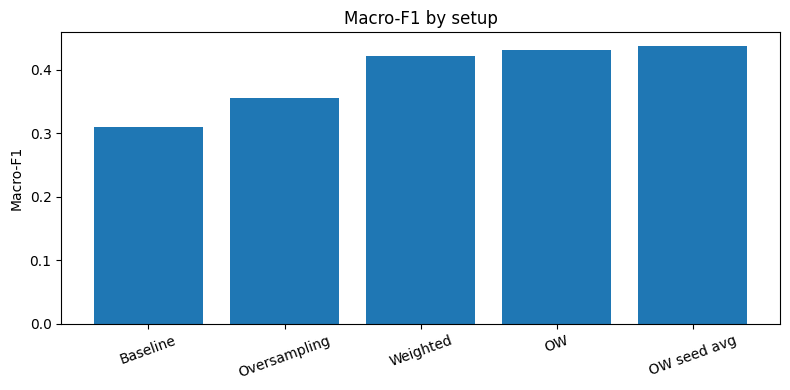

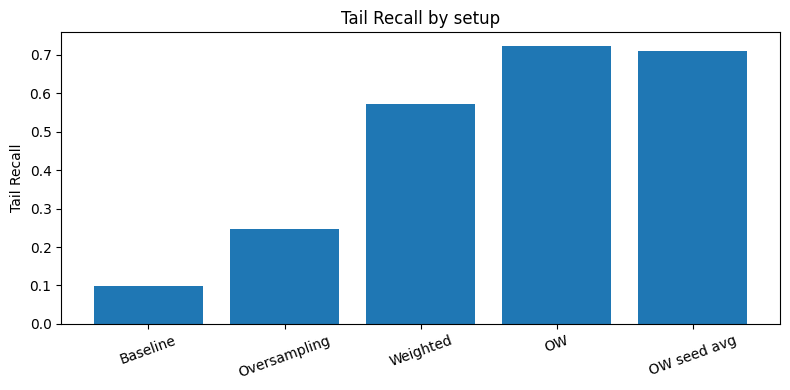

In [2]:
import matplotlib.pyplot as plt

setups = [
    "Baseline",
    "Oversampling",
    "Weighted",
    "OW",
    "OW seed avg",
]

macro_f1 = [0.3106, 0.3555, 0.4219, 0.4302, 0.4369]
tail_recall = [0.0986, 0.2464, 0.5714, 0.7216, 0.7099]

# Plot 1: Macro-F1
plt.figure(figsize=(8, 4))
plt.bar(setups, macro_f1)
plt.ylabel("Macro-F1")
plt.title("Macro-F1 by setup")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("macro_f1_by_setup.png", dpi=200, bbox_inches="tight")
plt.show()

# Plot 2: Tail Recall
plt.figure(figsize=(8, 4))
plt.bar(setups, tail_recall)
plt.ylabel("Tail Recall")
plt.title("Tail Recall by setup")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("tail_recall_by_setup.png", dpi=200, bbox_inches="tight")
plt.show()